Загружено 53940 записей из файла
Ограничено до 51000 записей (MAX_SAMPLES=51000)

Статистика по цене бриллиантов:
  Минимальная: $326
  Максимальная: $18823
  Средняя: $3927
  Медианная: $2401

Обучающая выборка: 35688 записей (70.0%)
Тестовая выборка: 15295 записей (30.0%)

НАША РЕАЛИЗАЦИЯ CART
Метрики качества (для цены бриллиантов):
  RMSE — корень из MSE, в долларах; чувствителен к выбросам.
  MAE  — средняя абсолютная ошибка, в долларах; интерпретируемая.
  R²   — доля объяснённой дисперсии (1 — идеально, 0 — как среднее).
  MAPE — средняя относительная ошибка, %.

Результаты обучения:

Наша модель (обучение):
  MSE:        1736664
  RMSE:       1318
  MAE:        741
  R²:         0.8907
  MAPE:       20.88%
  Median APE: 15.88%

  Квантили абсолютных ошибок:
    25%: 130
    50%: 329
    75%: 880
    90%: 1966
    95%: 2946

Наша модель (тест):
  MSE:        1654987
  RMSE:       1286
  MAE:        727
  R²:         0.8943
  MAPE:       20.89%
  Median APE: 15.83%

  Квантили аб

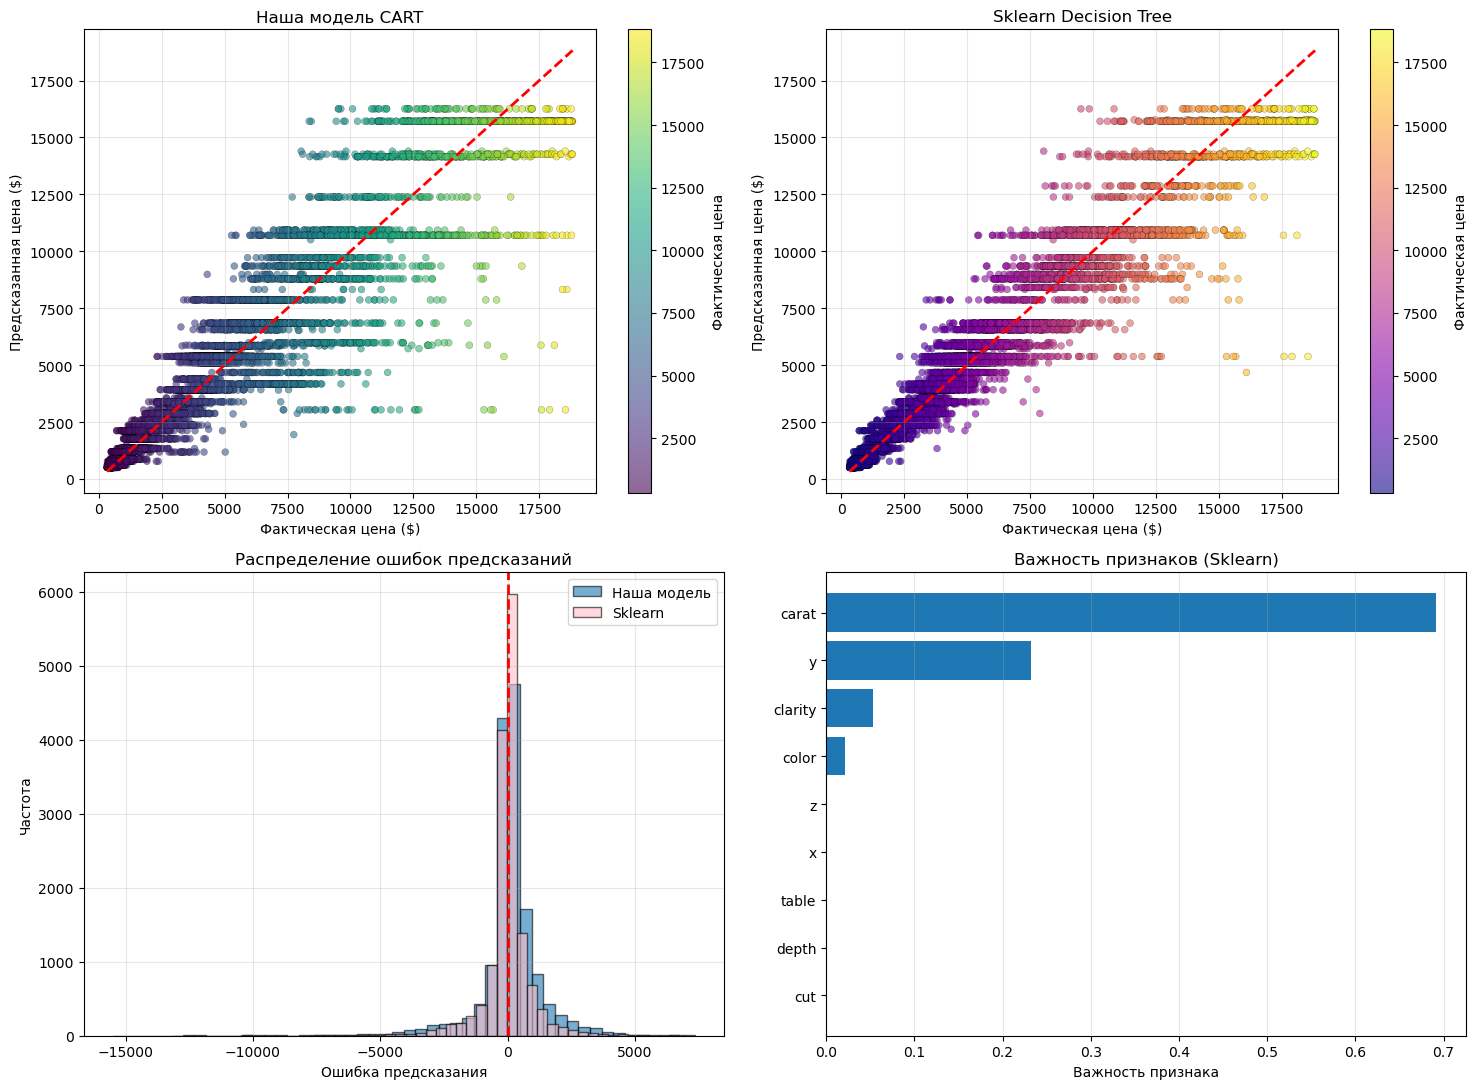

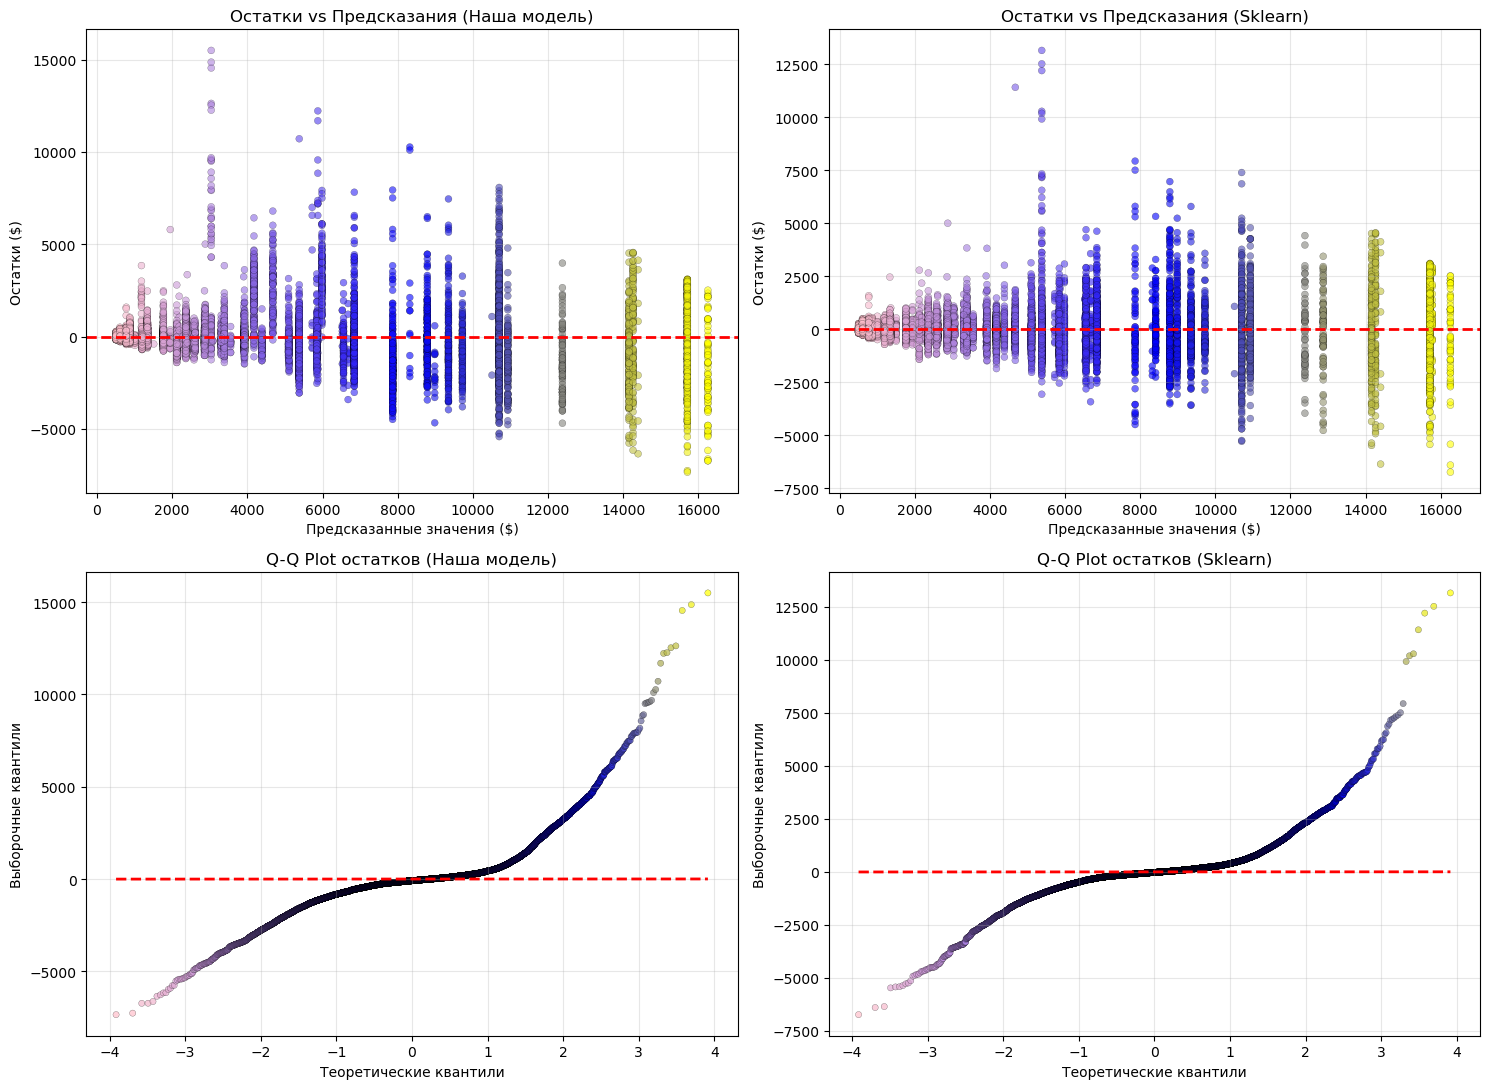

<Figure size 640x480 with 0 Axes>


АНАЛИЗ ОСТАТКОВ

Пояснения по анализу остатков:
  Шапиро–Уилк: проверяет нормальность ошибок (p>0.05 — ок).
  Дарбин–Уотсон: проверяет автокорреляцию (1.5–2.5 — ок).

Наша модель - Анализ остатков:
  Среднее остатков: -83.79
  Стандартное отклонение: 1283.73
  Медиана остатков: -90.29
  Тест Дарбина-Уотсона: 2.0018
    Нет автокорреляции остатков (1.5 < DW < 2.5)

Пояснения по анализу остатков:
  Шапиро–Уилк: проверяет нормальность ошибок (p>0.05 — ок).
  Дарбин–Уотсон: проверяет автокорреляцию (1.5–2.5 — ок).

Sklearn модель - Анализ остатков:
  Среднее остатков: 1.87
  Стандартное отклонение: 927.76
  Медиана остатков: -23.25
  Тест Дарбина-Уотсона: 1.9858
    Нет автокорреляции остатков (1.5 < DW < 2.5)

АНАЛИЗ ВАЖНОСТИ ПРИЗНАКОВ

Важность признаков:
Признак  Важность
  carat  0.691322
      y  0.232084
clarity  0.053556
  color  0.021226
      z  0.000953
      x  0.000860
    cut  0.000000
  depth  0.000000
  table  0.000000

ПРИМЕРЫ ПРЕДСКАЗАНИЙ

№  | Факт  | Наша модель | Sklea

In [7]:
"""
Регрессионный анализ для датасета бриллиантов

Программа повторяет подход из CART_regression_analysis.py, но адаптирована
под структуру файла с бриллиантами (carat, cut, color, clarity, depth, table, price, x, y, z).
"""

import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import cross_val_score, KFold, train_test_split
from scipy import stats
import matplotlib.pyplot as plt


# === НАСТРОЙКИ (МЕНЯЙТЕ ЗДЕСЬ!) ===
MAX_SAMPLES = 51000      # сколько строк использовать: 100, 500, 5000, None = все
TEST_SIZE = 0.3          # доля тестовой выборки: 0.2 = 20% тест, 80% обучение
CSV_PATH = r"C:\Users\Пользователь\Desktop\програмироание\mecanicoratrismeckanikkavenal\lab-5\diamonds.csv"
# ===================================


class Node:
    """Узел дерева решений"""
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value


class CARTRegressor:
    """Реализация CART алгоритма для регрессии"""
    def __init__(self, max_depth=5, min_samples_split=2, min_samples_leaf=1):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.root = None
        self.feature_names = None
        self.label_encoders = {}

    def mse(self, y):
        if len(y) == 0:
            return 0
        mean_val = np.mean(y)
        return np.mean((y - mean_val) ** 2)

    def best_split(self, X, y, feature_types=None):
        best_mse = float("inf")
        best_feature = None
        best_threshold = None
        best_indices = None

        n_features = X.shape[1]

        for feature in range(n_features):
            feature_values = np.unique(X[:, feature])
            if len(feature_values) < 2:
                continue

            if feature_types and feature_types[feature] == "categorical":
                for i in range(1, len(feature_values)):
                    threshold = feature_values[i]
                    left_indices = np.isin(X[:, feature], feature_values[:i])
                    right_indices = ~left_indices

                    y_left = y[left_indices]
                    y_right = y[right_indices]

                    if len(y_left) < self.min_samples_leaf or len(y_right) < self.min_samples_leaf:
                        continue

                    n_left, n_right = len(y_left), len(y_right)
                    n_total = n_left + n_right
                    mse_left = self.mse(y_left)
                    mse_right = self.mse(y_right)
                    mse_split = (n_left / n_total) * mse_left + (n_right / n_total) * mse_right

                    if mse_split < best_mse:
                        best_mse = mse_split
                        best_feature = feature
                        best_threshold = threshold
                        best_indices = (left_indices, right_indices)
            else:
                for i in range(len(feature_values) - 1):
                    threshold = (feature_values[i] + feature_values[i + 1]) / 2.0
                    left_indices = X[:, feature] <= threshold
                    right_indices = X[:, feature] > threshold

                    y_left = y[left_indices]
                    y_right = y[right_indices]

                    if len(y_left) < self.min_samples_leaf or len(y_right) < self.min_samples_leaf:
                        continue

                    n_left, n_right = len(y_left), len(y_right)
                    n_total = n_left + n_right
                    mse_left = self.mse(y_left)
                    mse_right = self.mse(y_right)
                    mse_split = (n_left / n_total) * mse_left + (n_right / n_total) * mse_right

                    if mse_split < best_mse:
                        best_mse = mse_split
                        best_feature = feature
                        best_threshold = threshold
                        best_indices = (left_indices, right_indices)

        return best_feature, best_threshold, best_indices

    def build_tree(self, X, y, depth=0, feature_types=None):
        if depth >= self.max_depth or len(y) < self.min_samples_split:
            return Node(value=np.mean(y))

        feature, threshold, indices = self.best_split(X, y, feature_types)
        if feature is None:
            return Node(value=np.mean(y))

        left_indices, right_indices = indices
        left_subtree = self.build_tree(X[left_indices], y[left_indices], depth + 1, feature_types)
        right_subtree = self.build_tree(X[right_indices], y[right_indices], depth + 1, feature_types)

        return Node(feature=feature, threshold=threshold, left=left_subtree, right=right_subtree)

    def fit(self, X, y, feature_names=None, feature_types=None):
        self.feature_names = feature_names

        if feature_types:
            X_encoded = X.copy()
            for i, (name, ftype) in enumerate(zip(feature_names, feature_types)):
                if ftype == "categorical":
                    le = LabelEncoder()
                    X_encoded[:, i] = le.fit_transform(X[:, i].astype(str))
                    self.label_encoders[i] = le
        else:
            X_encoded = X

        self.root = self.build_tree(X_encoded, y, feature_types=feature_types)
        return self

    def predict_single(self, x, node):
        if node.value is not None:
            return node.value
        if x[node.feature] <= node.threshold:
            return self.predict_single(x, node.left)
        return self.predict_single(x, node.right)

    def predict(self, X):
        predictions = []
        for x in X:
            x_encoded = x.copy()
            for i, le in self.label_encoders.items():
                if i < len(x):
                    try:
                        x_encoded[i] = le.transform([x[i]])[0]
                    except Exception:
                        x_encoded[i] = -1
            predictions.append(self.predict_single(x_encoded, self.root))
        return np.array(predictions)


def load_diamonds_data():
    """Загружает и подготавливает данные о бриллиантах из CSV"""
    try:
        df = pd.read_csv(CSV_PATH, encoding="utf-8")
        print(f"Загружено {len(df)} записей из файла")

        # Ограничиваем размер
        if MAX_SAMPLES is not None and len(df) > MAX_SAMPLES:
            df = df.sample(n=MAX_SAMPLES, random_state=42).reset_index(drop=True)
            print(f"Ограничено до {len(df)} записей (MAX_SAMPLES={MAX_SAMPLES})")

        target_col = "price"
        categorical_features = ["cut", "color", "clarity"]
        numeric_features = ["carat", "depth", "table", "x", "y", "z"]
        all_features = categorical_features + numeric_features

        # Убираем битые размеры
        df = df[(df[['x', 'y', 'z']] > 0).all(axis=1)]
        df = df.dropna(subset=[target_col] + all_features)

        df_encoded = df.copy()
        for feature in categorical_features:
            le = LabelEncoder()
            df_encoded[feature] = le.fit_transform(df[feature].astype(str))

        X = df_encoded[all_features].values
        y = df[target_col].values
        feature_types = ["categorical"] * len(categorical_features) + ["numeric"] * len(numeric_features)

        print(f"\nСтатистика по цене бриллиантов:")
        print(f"  Минимальная: ${y.min():.0f}")
        print(f"  Максимальная: ${y.max():.0f}")
        print(f"  Средняя: ${y.mean():.0f}")
        print(f"  Медианная: ${np.median(y):.0f}")

        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=TEST_SIZE, random_state=42
        )

        print(f"\nОбучающая выборка: {len(X_train)} записей ({(1 - TEST_SIZE) * 100:.1f}%)")
        print(f"Тестовая выборка: {len(X_test)} записей ({TEST_SIZE * 100:.1f}%)")

        return X_train, X_test, y_train, y_test, all_features, feature_types

    except Exception as e:
        print(f"Ошибка при загрузке датасета: {e}")
        return None


def evaluate_model(y_true, y_pred, name=""):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    median_ape = np.median(np.abs((y_true - y_pred) / y_true)) * 100
    abs_errors = np.abs(y_true - y_pred)
    q25 = np.percentile(abs_errors, 25)
    q50 = np.median(abs_errors)
    q75 = np.percentile(abs_errors, 75)
    q90 = np.percentile(abs_errors, 90)
    q95 = np.percentile(abs_errors, 95)

    print(f"\n{name}:")
    print(f"  MSE:        {mse:.0f}")
    print(f"  RMSE:       {rmse:.0f}")
    print(f"  MAE:        {mae:.0f}")
    print(f"  R²:         {r2:.4f}")
    print(f"  MAPE:       {mape:.2f}%")
    print(f"  Median APE: {median_ape:.2f}%")
    print(f"\n  Квантили абсолютных ошибок:")
    print(f"    25%: {q25:.0f}")
    print(f"    50%: {q50:.0f}")
    print(f"    75%: {q75:.0f}")
    print(f"    90%: {q90:.0f}")
    print(f"    95%: {q95:.0f}")

    return mse, rmse, mae, r2, mape


def analyze_residuals(y_true, y_pred, model_name=""):
    residuals = y_true - y_pred

    print("\nПояснения по анализу остатков:")
    print("  Шапиро–Уилк: проверяет нормальность ошибок (p>0.05 — ок).")
    print("  Дарбин–Уотсон: проверяет автокорреляцию (1.5–2.5 — ок).")

    print(f"\n{model_name} - Анализ остатков:")
    print(f"  Среднее остатков: {np.mean(residuals):.2f}")
    print(f"  Стандартное отклонение: {np.std(residuals):.2f}")
    print(f"  Медиана остатков: {np.median(residuals):.2f}")

    if len(residuals) <= 5000:
        stat, p_value = stats.shapiro(residuals)
        print(f"  Тест Шапиро-Уилка: статистика={stat:.4f}, p-value={p_value:.4f}")
        if p_value > 0.05:
            print("    Остатки распределены нормально (p > 0.05)")
        else:
            print("    Остатки НЕ распределены нормально (p <= 0.05)")

    diff_residuals = np.diff(residuals)
    dw_stat = np.sum(diff_residuals ** 2) / np.sum(residuals ** 2)
    print(f"  Тест Дарбина-Уотсона: {dw_stat:.4f}")
    if 1.5 < dw_stat < 2.5:
        print("    Нет автокорреляции остатков (1.5 < DW < 2.5)")
    else:
        print("    Возможна автокорреляция остатков")

    return residuals


def visualize_results(y_test, y_pred_our, y_pred_sk, feature_names, sklearn_model):
    fig, axes = plt.subplots(2, 2, figsize=(15, 11))

    ax1 = axes[0, 0]
    scatter1 = ax1.scatter(y_test, y_pred_our, c=y_test, cmap='viridis', alpha=0.6, s=25, edgecolor='k', linewidth=0.2)
    min_price = min(y_test.min(), y_pred_our.min())
    max_price = max(y_test.max(), y_pred_our.max())
    ax1.plot([min_price, max_price], [min_price, max_price], "r--", lw=2)
    ax1.set_xlabel("Фактическая цена ($)")
    ax1.set_ylabel("Предсказанная цена ($)")
    ax1.set_title("Наша модель CART")
    ax1.grid(True, alpha=0.3)
    fig.colorbar(scatter1, ax=ax1, label='Фактическая цена')

    ax2 = axes[0, 1]
    scatter2 = ax2.scatter(y_test, y_pred_sk, c=y_test, cmap='plasma', alpha=0.6, s=25, edgecolor='k', linewidth=0.2)
    ax2.plot([min_price, max_price], [min_price, max_price], "r--", lw=2)
    ax2.set_xlabel("Фактическая цена ($)")
    ax2.set_ylabel("Предсказанная цена ($)")
    ax2.set_title("Sklearn Decision Tree")
    ax2.grid(True, alpha=0.3)
    fig.colorbar(scatter2, ax=ax2, label='Фактическая цена')

    ax3 = axes[1, 0]
    errors_our = y_pred_our - y_test
    errors_sk = y_pred_sk - y_test
    ax3.hist(errors_our, bins=50, alpha=0.6, label="Наша модель", edgecolor="black")
    ax3.hist(errors_sk, bins=50, alpha=0.6, label="Sklearn", edgecolor="black", color="pink")
    ax3.axvline(x=0, color="r", linestyle="--", linewidth=2)
    ax3.set_xlabel("Ошибка предсказания")
    ax3.set_ylabel("Частота")
    ax3.set_title("Распределение ошибок предсказаний")
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    ax4 = axes[1, 1]
    if hasattr(sklearn_model, "feature_importances_"):
        importances = sklearn_model.feature_importances_
        indices = np.argsort(importances)
        ax4.barh(range(len(indices)), importances[indices])
        ax4.set_yticks(range(len(indices)))
        ax4.set_yticklabels([feature_names[i] for i in indices])
        ax4.set_xlabel("Важность признака")
        ax4.set_title("Важность признаков (Sklearn)")
        ax4.grid(True, alpha=0.3, axis="x")

    plt.tight_layout()
    plt.show()

    # Блок 2: анализ остатков с градиентной раскраской (включая Q-Q)
    residuals_our = y_test - y_pred_our
    residuals_sk = y_test - y_pred_sk

    fig, axes = plt.subplots(2, 2, figsize=(15, 11))

    # --- Остатки vs Предсказания (Наша модель) ---
    ax1 = axes[0, 0]
    pred_norm_our = (y_pred_our - y_pred_our.min()) / (y_pred_our.max() - y_pred_our.min() + 1e-8)
    from matplotlib.colors import LinearSegmentedColormap
    cmap_custom = LinearSegmentedColormap.from_list("pink_blue_yellow", ["pink", "blue", "yellow"])
    colors_our = cmap_custom(pred_norm_our)
    ax1.scatter(y_pred_our, residuals_our, c=colors_our, alpha=0.6, s=25, edgecolor='k', linewidth=0.2)
    ax1.axhline(y=0, color="red", linestyle="--", linewidth=2)
    ax1.set_xlabel("Предсказанные значения ($)")
    ax1.set_ylabel("Остатки ($)")
    ax1.set_title("Остатки vs Предсказания (Наша модель)")
    ax1.grid(True, alpha=0.3)

    # --- Остатки vs Предсказания (Sklearn) ---
    ax2 = axes[0, 1]
    pred_norm_sk = (y_pred_sk - y_pred_sk.min()) / (y_pred_sk.max() - y_pred_sk.min() + 1e-8)
    colors_sk = cmap_custom(pred_norm_sk)
    ax2.scatter(y_pred_sk, residuals_sk, c=colors_sk, alpha=0.6, s=25, edgecolor='k', linewidth=0.2)
    ax2.axhline(y=0, color="red", linestyle="--", linewidth=2)
    ax2.set_xlabel("Предсказанные значения ($)")
    ax2.set_ylabel("Остатки ($)")
    ax2.set_title("Остатки vs Предсказания (Sklearn)")
    ax2.grid(True, alpha=0.3)

    # --- Q-Q Plot (Наша модель) с градиентом ---
    ax3 = axes[1, 0]
    osm_our, osr_our = stats.probplot(residuals_our, dist="norm", fit=False)
    # Цвет по величине остатков (или по позиции)
    residual_norm_our = (osr_our - osr_our.min()) / (osr_our.max() - osr_our.min() + 1e-8)
    colors_qq_our = cmap_custom(residual_norm_our)
    ax3.scatter(osm_our, osr_our, c=colors_qq_our, alpha=0.7, s=20, edgecolor='k', linewidth=0.2)
    # Линия y = x (теоретическая)
    ax3.plot([osm_our.min(), osm_our.max()], [osm_our.min(), osm_our.max()], "r--", lw=2)
    ax3.set_xlabel("Теоретические квантили")
    ax3.set_ylabel("Выборочные квантили")
    ax3.set_title("Q-Q Plot остатков (Наша модель)")
    ax3.grid(True, alpha=0.3)

    # --- Q-Q Plot (Sklearn) с градиентом ---
    ax4 = axes[1, 1]
    osm_sk, osr_sk = stats.probplot(residuals_sk, dist="norm", fit=False)
    residual_norm_sk = (osr_sk - osr_sk.min()) / (osr_sk.max() - osr_sk.min() + 1e-8)
    colors_qq_sk = cmap_custom(residual_norm_sk)
    ax4.scatter(osm_sk, osr_sk, c=colors_qq_sk, alpha=0.7, s=20, edgecolor='k', linewidth=0.2)
    ax4.plot([osm_sk.min(), osm_sk.max()], [osm_sk.min(), osm_sk.max()], "r--", lw=2)
    ax4.set_xlabel("Теоретические квантили")
    ax4.set_ylabel("Выборочные квантили")
    ax4.set_title("Q-Q Plot остатков (Sklearn)")
    ax4.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    ax1 = axes[0, 0]
    ax1.scatter(y_pred_our, residuals_our, alpha=0.5, s=20)
    ax1.axhline(y=0, color="r", linestyle="--", linewidth=2)
    ax1.set_xlabel("Предсказанные значения")
    ax1.set_ylabel("Остатки")
    ax1.set_title("Остатки vs Предсказания (Наша модель)")
    ax1.grid(True, alpha=0.3)

    ax2 = axes[0, 1]
    ax2.scatter(y_pred_sk, residuals_sk, alpha=0.5, s=20, color="orange")
    ax2.axhline(y=0, color="r", linestyle="--", linewidth=2)
    ax2.set_xlabel("Предсказанные значения")
    ax2.set_ylabel("Остатки")
    ax2.set_title("Остатки vs Предсказания (Sklearn)")
    ax2.grid(True, alpha=0.3)

    ax3 = axes[1, 0]
    stats.probplot(residuals_our, dist="norm", plot=ax3)
    ax3.set_title("Q-Q Plot остатков (Наша модель)")
    ax3.grid(True, alpha=0.3)

    ax4 = axes[1, 1]
    stats.probplot(residuals_sk, dist="norm", plot=ax4)
    ax4.set_title("Q-Q Plot остатков (Sklearn)")
    ax4.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def main():
    data = load_diamonds_data()
    if data is None:
        return

    X_train, X_test, y_train, y_test, feature_names, feature_types = data

    print("\n" + "=" * 60)
    print("НАША РЕАЛИЗАЦИЯ CART")
    print("=" * 60)
    print("Метрики качества (для цены бриллиантов):")
    print("  RMSE — корень из MSE, в долларах; чувствителен к выбросам.")
    print("  MAE  — средняя абсолютная ошибка, в долларах; интерпретируемая.")
    print("  R²   — доля объяснённой дисперсии (1 — идеально, 0 — как среднее).")
    print("  MAPE — средняя относительная ошибка, %.")

    cart_model = CARTRegressor(max_depth=6, min_samples_split=10, min_samples_leaf=5)
    cart_model.fit(X_train, y_train, feature_names=feature_names, feature_types=feature_types)

    y_train_pred = cart_model.predict(X_train)
    y_test_pred = cart_model.predict(X_test)

    print("\nРезультаты обучения:")
    evaluate_model(y_train, y_train_pred, "Наша модель (обучение)")
    evaluate_model(y_test, y_test_pred, "Наша модель (тест)")

    print("\n" + "=" * 60)
    print("SKLEARN ДЕРЕВО РЕШЕНИЙ")
    print("=" * 60)

    sklearn_model = DecisionTreeRegressor(
        max_depth=6,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42,
    )
    sklearn_model.fit(X_train, y_train)

    y_train_pred_sk = sklearn_model.predict(X_train)
    y_test_pred_sk = sklearn_model.predict(X_test)

    evaluate_model(y_train, y_train_pred_sk, "Sklearn (обучение)")
    evaluate_model(y_test, y_test_pred_sk, "Sklearn (тест)")

    print("\n" + "=" * 60)
    print("АНАЛИЗ ПЕРЕОБУЧЕНИЯ")
    print("=" * 60)

    train_r2_our = r2_score(y_train, y_train_pred)
    test_r2_our = r2_score(y_test, y_test_pred)
    train_r2_sk = r2_score(y_train, y_train_pred_sk)
    test_r2_sk = r2_score(y_test, y_test_pred_sk)

    print("\nНаша модель:")
    print(f"  R² на обучении: {train_r2_our:.4f}")
    print(f"  R² на тесте:    {test_r2_our:.4f}")
    print(f"  Разница:        {train_r2_our - test_r2_our:.4f}")
    if train_r2_our - test_r2_our > 0.1:
        print("  ⚠️  Возможно переобучение (разница > 0.1)")
    else:
        print("  ✓ Модель обобщается хорошо")

    print("\nSklearn:")
    print(f"  R² на обучении: {train_r2_sk:.4f}")
    print(f"  R² на тесте:    {test_r2_sk:.4f}")
    print(f"  Разница:        {train_r2_sk - test_r2_sk:.4f}")
    if train_r2_sk - test_r2_sk > 0.1:
        print("  ⚠️  Возможно переобучение (разница > 0.1)")
    else:
        print("  ✓ Модель обобщается хорошо")

    print("\n" + "=" * 60)
    print("КРОСС-ВАЛИДАЦИЯ (5-Fold)")
    print("=" * 60)
    try:
        kfold = KFold(n_splits=5, shuffle=True, random_state=42)
        cv_scores_sk = cross_val_score(
            sklearn_model, X_train, y_train, cv=kfold, scoring="r2", n_jobs=-1
        )
        print("\nSklearn модель (R²):")
        print(f"  Среднее: {cv_scores_sk.mean():.4f} (+/- {cv_scores_sk.std() * 2:.4f})")
        print(f"  Отдельные fold'ы: {[f'{s:.4f}' for s in cv_scores_sk]}")
    except Exception as e:
        print(f"Кросс-валидация для sklearn модели не выполнена: {e}")

    visualize_results(y_test, y_test_pred, y_test_pred_sk, feature_names, sklearn_model)

    print("\n" + "=" * 60)
    print("АНАЛИЗ ОСТАТКОВ")
    print("=" * 60)
    analyze_residuals(y_test, y_test_pred, "Наша модель")
    analyze_residuals(y_test, y_test_pred_sk, "Sklearn модель")

    print("\n" + "=" * 60)
    print("АНАЛИЗ ВАЖНОСТИ ПРИЗНАКОВ")
    print("=" * 60)
    if hasattr(sklearn_model, "feature_importances_"):
        importance_df = (
            pd.DataFrame({"Признак": feature_names, "Важность": sklearn_model.feature_importances_})
            .sort_values("Важность", ascending=False)
        )
        print("\nВажность признаков:")
        print(importance_df.to_string(index=False))

    print("\n" + "=" * 60)
    print("ПРИМЕРЫ ПРЕДСКАЗАНИЙ")
    print("=" * 60)
    print("\n№  | Факт  | Наша модель | Sklearn | Ошибка (наша) | Ошибка (sklearn)")
    print("-" * 80)

    n_examples = min(15, len(y_test))
    sample_indices = np.random.choice(len(y_test), n_examples, replace=False)
    for i, idx in enumerate(sample_indices):
        actual = y_test[idx]
        pred_our = y_test_pred[idx]
        pred_sk = y_test_pred_sk[idx]
        error_our = pred_our - actual
        error_sk = pred_sk - actual
        print(
            f"{i + 1:2d} | {actual:7.0f} | {pred_our:12.0f} | {pred_sk:7.0f} | "
            f"{error_our:13.0f} | {error_sk:15.0f}"
        )

    print("\n" + "=" * 60)
    print("СТАТИСТИКА ПО ОШИБКАМ")
    print("=" * 60)
    abs_errors_our = np.abs(y_test_pred - y_test)
    abs_errors_sk = np.abs(y_test_pred_sk - y_test)
    print("\nНаша модель:")
    print(f"  Средняя абсолютная ошибка: {np.mean(abs_errors_our):.0f}")
    print(f"  Медианная абсолютная ошибка: {np.median(abs_errors_our):.0f}")
    print(f"  Максимальная ошибка: {np.max(abs_errors_our):.0f}")
    print("\nSklearn:")
    print(f"  Средняя абсолютная ошибка: {np.mean(abs_errors_sk):.0f}")
    print(f"  Медианная абсолютная ошибка: {np.median(abs_errors_sk):.0f}")
    print(f"  Максимальная ошибка: {np.max(abs_errors_sk):.0f}")

    correlation = np.corrcoef(y_test_pred, y_test_pred_sk)[0, 1]
    print(f"\nКорреляция между предсказаниями моделей: {correlation:.4f}")

    baseline_pred = np.full_like(y_test, np.mean(y_train))
    baseline_r2 = r2_score(y_test, baseline_pred)
    baseline_mae = mean_absolute_error(y_test, baseline_pred)
    print("\n" + "=" * 60)
    print("СРАВНЕНИЕ С BASELINE (среднее значение)")
    print("=" * 60)
    print("\nBaseline (среднее значение):")
    print(f"  R²:  {baseline_r2:.4f}")
    print(f"  MAE: {baseline_mae:.0f}")
    print("\nУлучшение нашей модели относительно baseline:")
    print(
        f"  R²:  {test_r2_our - baseline_r2:.4f} "
        f"({((test_r2_our - baseline_r2) / abs(baseline_r2) * 100):.1f}%)"
    )
    print(
        f"  MAE: {baseline_mae - np.mean(abs_errors_our):.0f} "
        f"({((baseline_mae - np.mean(abs_errors_our)) / baseline_mae * 100):.1f}% улучшение)"
    )

    print("\n" + "=" * 60)
    print("ИТОГОВОЕ РЕЗЮМЕ")
    print("=" * 60)
    print("\nЛучшая модель на тестовой выборке:")
    if test_r2_our > test_r2_sk:
        print(f"  Наша модель CART (R² = {test_r2_our:.4f})")
    else:
        print(f"  Sklearn Decision Tree (R² = {test_r2_sk:.4f})")

    print("\nКачество модели:")
    if max(test_r2_our, test_r2_sk) > 0.9:
        print("  Отличное (R² > 0.9)")
    elif max(test_r2_our, test_r2_sk) > 0.7:
        print("  Хорошее (0.7 < R² <= 0.9)")
    elif max(test_r2_our, test_r2_sk) > 0.5:
        print("  Удовлетворительное (0.5 < R² <= 0.7)")
    else:
        print("  Требует улучшения (R² <= 0.5)")


if __name__ == "__main__":
    main()